Team: Anna Moy & Natalie Kalukeerthie

For this assignment, we use the Harry Potter dataset to analyze character interactions, incorporating categorical information such as gender. The dataset we decided to use is from

**Github : Character Interaction Networks for the Harry Potter Series**
(https://github.com/nikhil-ravi/harry-potter-interactions?tab=readme-ov-file)


*   Characters - Contains the list of characters in the Harry Potter book series
*   Edges - Contains the network interactions between the characters

We incorporated another file to get the categorical variable gender into our analysis which we got from

**Kaggle : Harry Potter Dataset**
(https://www.kaggle.com/datasets/gulsahdemiryurek/harry-potter-dataset?resource=download)



*   Characters - Contains the list of characters, gender, job, house, and other information pertaining to the character




In [14]:
#Load the libraries
import pandas as pd
!pip install thefuzz[speedup] networkx pandas
from thefuzz import process
import networkx as nx
from scipy.stats import ttest_ind
import matplotlib.pyplot as pl
from matplotlib.lines import Line2D

We loaded the three dataset we got from Github and Kaggle on the Harry Potter information and took a look at the first 5 rows for each dataset to look at the layout of the information.

In [15]:
#Load Files
character_df = pd.read_csv('https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/HP_character.csv')
gender_df = pd.read_csv('https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/Characters.csv', sep=';')
edges_df = pd.read_csv('https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/hp_all_edges.csv')

print("Character DF:")
print(character_df.head())

print("\nGender DF:")
print(gender_df.head())

print("\nEdges DF:")
print(edges_df.head())

Character DF:
   book_chapter        character
0           101   Vernon Dursley
1           101  Petunia Dursley
2           101   Dudley Dursley
3           101   Lily J. Potter
4           101   James Potter I

Gender DF:
   Id                                     Name  Gender  \
0   1                       Harry James Potter    Male   
1   2                    Ronald Bilius Weasley    Male   
2   3                    Hermione Jean Granger  Female   
3   4  Albus Percival Wulfric Brian Dumbledore    Male   
4   5                            Rubeus Hagrid    Male   

                                                 Job       House  \
0                                            Student  Gryffindor   
1                                            Student  Gryffindor   
2                                            Student  Gryffindor   
3                                         Headmaster  Gryffindor   
4  Keeper of Keys and Grounds | Professor of Care...  Gryffindor   

                  

To extract gender, house, and job information for each character into the GitHub interaction dataset, we combined it with a second dataset containing detailed character attributes. Since the character names in the two datasets were not formatted identically, we used fuzzy matching to align them. Fuzzy matching allowed us to match character names based on similarity score and if it matched 80% we would consider it a match. Once the datasets were successfully merged, we verified the results by displaying the first few rows to ensure the gender, house, and job fields were correctly matched and populated.

In [16]:
# Fuzzy match function
def fuzzy_match(name, choices, threshold=80):
    match, score = process.extractOne(name, choices)
    return match if score >= threshold else None

# Apply fuzzy matching
character_df['matched_name'] = character_df['character'].apply(
    lambda x: fuzzy_match(x, gender_df['Name'].tolist())
)

# Merge matched data
merged_df = pd.merge(character_df, gender_df, left_on='matched_name', right_on='Name', how='left')

# Show sample results
merged_df[['character', 'matched_name', 'Gender', 'House', 'Job']].head()

,character,matched_name,Gender,House,Job
0,Vernon Dursley,Vernon Dursley,Male,NaN,Director at Grunnings
1,Petunia Dursley,Petunia Dursley,Female,NaN,NaN
2,Dudley Dursley,Dudley Dursley,Male,NaN,NaN
3,Lily J. Potter,Lily J. Potter,Female,Gryffindor,NaN
4,James Potter I,James Potter,Male,Gryffindor,NaN


Once we have the merged data we took a look to see how many matches we have out of the original data.

In [17]:
matched_count = merged_df['matched_name'].notna().sum()
total_count = len(merged_df)

print(f"Matched characters: {matched_count} out of {total_count}")
print(f"Match rate: {matched_count / total_count:.2%}")

Matched characters: 244 out of 750
Match rate: 32.53%


Next we created a Networkx graph from the edge dataset which contains the interactions between the characters which indicates the intensity of their connection. We dropped the duplicates character rows and index the character column and made it into a dictionary format which creates a row for each character and their attributes.

In [18]:
# Create weighted undirected graph
G = nx.from_pandas_edgelist(edges_df, source='source', target='target', edge_attr='weight')

# Drop duplicate character rows
attribute_dict = (
    merged_df
    .drop_duplicates(subset='character')  # Ensure one row per character
    .set_index('character')
    .to_dict('index')
)

We add the attribute information to the nodes in the network, alongside the edge data, so we can analyze centrality measures (like degree and eigenvector centrality) while considering character details such as gender or house.

**Degree of centrality** : Measures how many connections each character has

**Eigenvector centrality**: Meaures how important or influential a character is based on their connection.

We created a dataframe which stores the degree of centrality and eigenvector centrality of each character and then merging the characters detail with it.  Then we took the a look at the degree of centrality and eigenvector centrality average by gender.

The results indicate that male characters in the Harry Potter network tend to have more connections and hold more influential positions compared to female characters. This is true from our perspective as we read or watched the Harry Potter series we know the main characters are two male (Harry Potter & Ron Weasley) and one female (Hermione granger).

In [19]:
# Add attributes
nx.set_node_attributes(G, attribute_dict)

# Compute centralities
degree_centrality = nx.degree_centrality(G)
eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Store centrality results
centrality_df = pd.DataFrame({
    'character': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'eigenvector_centrality': [eigen_centrality.get(node, 0) for node in degree_centrality.keys()]
})

# Merge with gender/house/job
centrality_df = pd.merge(
    centrality_df,
    merged_df[['character', 'Gender', 'House', 'Job']],
    on='character',
    how='left'
)

# Group by Gender
centrality_by_gender = centrality_df.groupby('Gender')[['degree_centrality', 'eigenvector_centrality']].mean()
print(centrality_by_gender)

        degree_centrality  eigenvector_centrality
Gender                                           
Female           0.068763                0.052460
Male             0.084352                0.058373


We used the gender information to conduct t-tests comparing centrality measures between male and female characters. First, we removed any entries with missing gender data. Then, we separated the degree centrality and eigenvector centrality scores into two groups based on gender and performed independent t-tests.

T-test : Is conducting a statistical test to determine if there is a significant difference between the means of the two groups.


*   P-value <0.05 - Significant difference
*   P-value >= 0.05 - No significant difference



The results showed that for degree centrality, the p-value was 0.2799, which is greater than the typical significance threshold of 0.05. This indicates that the difference in the number of connections between male and female characters is not statistically significant. Similarly, the eigenvector centrality t-test yielded a p-value of 0.4312, also above 0.05, suggesting no significant difference in influence between male and female characters.

**Conclusion:** There is no statistical evidence to suggest that male and female characters differ significantly in terms of their network connectivity or influence within the Harry Potter character network. Given the small dataset it may be harder to find significant differences

In [20]:
# Drop missing gender data
clean_df = centrality_df.dropna(subset=['Gender'])

# Split centrality scores by gender
male_degree = clean_df[clean_df['Gender'] == 'Male']['degree_centrality']
female_degree = clean_df[clean_df['Gender'] == 'Female']['degree_centrality']

male_eigen = clean_df[clean_df['Gender'] == 'Male']['eigenvector_centrality']
female_eigen = clean_df[clean_df['Gender'] == 'Female']['eigenvector_centrality']

# Perform t-tests
t_deg, p_deg = ttest_ind(male_degree, female_degree, equal_var=False)
t_eigen, p_eigen = ttest_ind(male_eigen, female_eigen, equal_var=False)

# Show results
print(f"Degree Centrality T-test: t = {t_deg:.3f}, p = {p_deg:.4f}")
print(f"Eigenvector Centrality T-test: t = {t_eigen:.3f}, p = {p_eigen:.4f}")

Degree Centrality T-test: t = 1.085, p = 0.2799
Eigenvector Centrality T-test: t = 0.790, p = 0.4312


Besides analyzing degree centrality and eigenvector centrality by gender, we also examined these centrality measures by house.

In [21]:
# Group by Job and calculate mean centralities
centrality_by_job = centrality_df.groupby('House')[['degree_centrality', 'eigenvector_centrality']].mean()

# Print the results
print(centrality_by_job.sort_values(by='degree_centrality', ascending=False))


                              degree_centrality  eigenvector_centrality
House                                                                  
Gryffindor                             0.119260                0.074721
Durmstrang Institute                   0.100629                0.077069
Slytherin                              0.074292                0.053835
Beauxbatons Academy of Magic           0.064291                0.058270
Ravenclaw                              0.060907                0.052188
Hufflepuff                             0.052895                0.043570


Our analysis showed that Gryffindor characters have the highest degree centrality and also a relatively high eigenvector centrality, these results coincide with the movies since the main storyline follows Gryffindor students and they tend to interact with more characters overall. Higher degree centrality also indicate that Gryffindors are more socially connected within the Harry Potter universe, potentially giving them more influence in spreading information or mobilizing others during key events.

Meanwhile, characters from Durmstrang Institute exhibit the highest eigenvector centrality, suggesting they hold the most influence overall.



By building a network graph of the top 15 most central characters (highlighted large red Gryffindor nodes) like Harry, Hermione, and Dumbledore, we see that they dominate the core of the network, while other Houses appeared smaller and more peripheral.

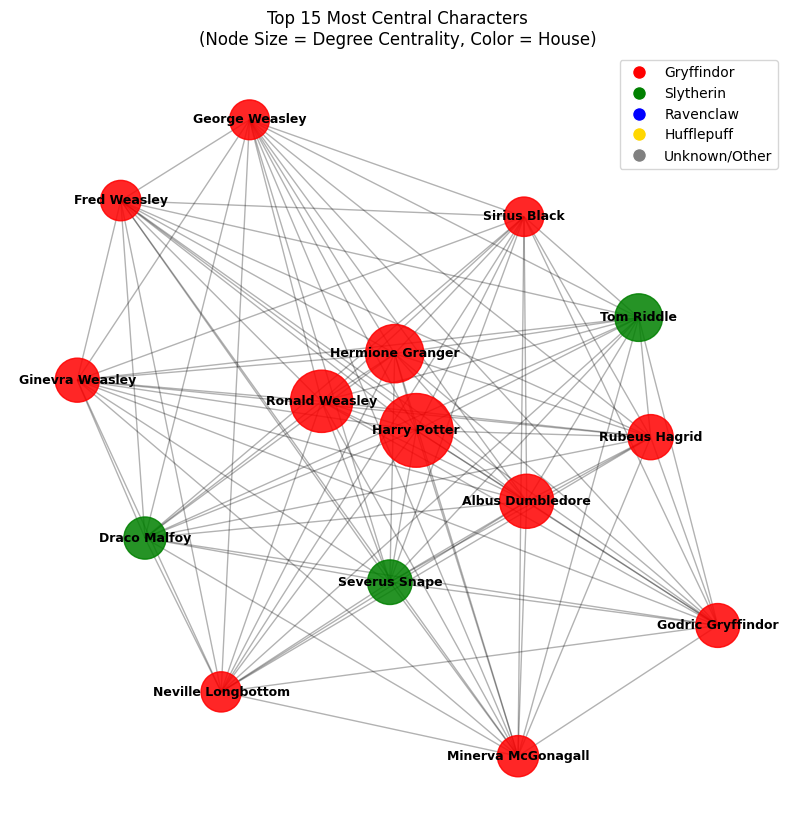

In [22]:
# --- Filter: Keep only the top N most central characters ---
N = 15  # change to 10, 20, etc. depending on how many you want

# Get top N characters by degree centrality
top_characters = (
    centrality_df
    .sort_values(by="degree_centrality", ascending=False)
    .head(N)['character']
    .tolist()
)

# Create subgraph of only top characters
subG = G.subgraph(top_characters)

# Define colors for each Hogwarts house
house_colors = {
    'Gryffindor': 'red',
    'Slytherin': 'green',
    'Ravenclaw': 'blue',
    'Hufflepuff': 'gold',
    'Unknown': 'gray',
    'Other': 'gray'
}

# Get attributes for subgraph
node_colors = []
node_sizes = []
for node in subG.nodes():
    house = subG.nodes[node].get('House', 'Unknown')
    color = house_colors.get(house, 'gray')
    node_colors.append(color)
    node_sizes.append(degree_centrality.get(node, 0) * 4000)  # larger scale since fewer nodes

# Layout
pos = nx.spring_layout(subG, k=0.5, seed=42)

pl.figure(figsize=(10, 10))
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(subG, pos, alpha=0.3, width=1.0)
nx.draw_networkx_labels(subG, pos, font_size=9, font_weight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Gryffindor', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Slytherin', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Ravenclaw', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Hufflepuff', markerfacecolor='gold', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Unknown/Other', markerfacecolor='gray', markersize=10)
]
pl.legend(handles=legend_elements, loc="best")

pl.title(f"Top {N} Most Central Characters\n(Node Size = Degree Centrality, Color = House)")
pl.axis("off")
pl.show()
